## ⚖️ Handling Imbalanced Datasets

In classification problems, an **imbalanced dataset** means one class has significantly more samples than the other(s).

This can lead to **biased models** that favor the majority class.

---

### 🔼 1. Up Sampling (Over Sampling)

Increase the number of samples in the **minority class** by duplicating existing samples or generating synthetic ones.

📌 **Pros:**
- More balanced data
- Useful when data is limited

⚠️ **Cons:**
- May lead to overfitting


### 🔽 2. Down Sampling (Under Sampling)

Reduce the number of samples in the **majority class** to match the **minority class**.

---

📌 **Pros**:
- ⚡ Faster training
- 💾 Reduces memory usage

⚠️ **Cons**:
- ❗ Risk of losing important information


In [1]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

n_class_0,n_class_1

(900, 100)

In [2]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [3]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [7]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

Up sampled

In [8]:
## upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [9]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

In [11]:
df_minority_upsampled

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1
...,...,...,...
952,1.188902,2.189189,1
965,3.919526,1.980541,1
976,2.810326,3.604614,1
942,3.621531,2.168229,1


In [12]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [13]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

Down sampled

In [15]:
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=False, #Sample With replacement
         n_samples=len(df_minority),
         random_state=42
        )

In [16]:
df_majority_downsampled

,feature_1,feature_2,target
70,0.468439,1.720920,0
827,1.089165,-0.464899,0
231,0.753869,-0.969798,0
588,0.588686,-0.704720,0
39,0.283627,1.012868,0
...,...,...,...
398,-0.168426,0.553775,0
76,-0.403366,0.081491,0
196,-0.269293,0.611238,0
631,-0.295829,0.671673,0


In [17]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])

In [18]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])

## 🔁 SMOTE (Synthetic Minority Over-sampling Technique)

**SMOTE** is a technique to handle imbalanced datasets by creating **synthetic examples** of the minority class instead of duplicating existing ones.

### 💡 How it works:
- Selects a minority class sample.
- Finds its **k-nearest neighbors** (usually k=5).
- Creates **new synthetic samples** along the line between the selected sample and its neighbors.

---

📌 **Pros**:
- Reduces overfitting caused by random oversampling.
- Improves model performance on imbalanced data.

⚠️ **Cons**:
- Can create ambiguous or overlapping class regions.
- Not ideal for categorical data without encoding.

---


In [19]:
from sklearn.datasets import make_classification

In [20]:
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)

In [22]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [23]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

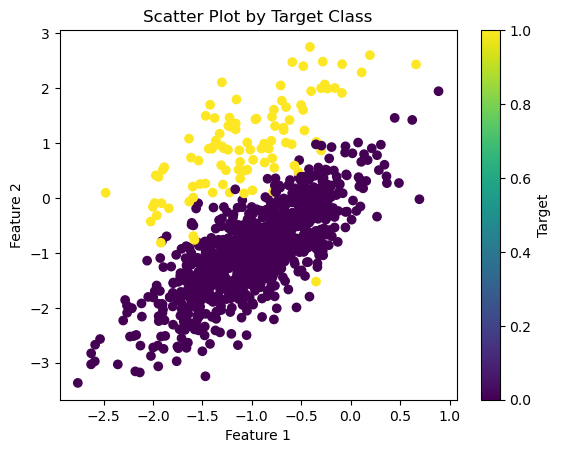

In [26]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot by Target Class')
plt.colorbar(label='Target')
plt.show()


In [27]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [28]:
from imblearn.over_sampling import SMOTE

In [29]:
## transform the dataset
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [30]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

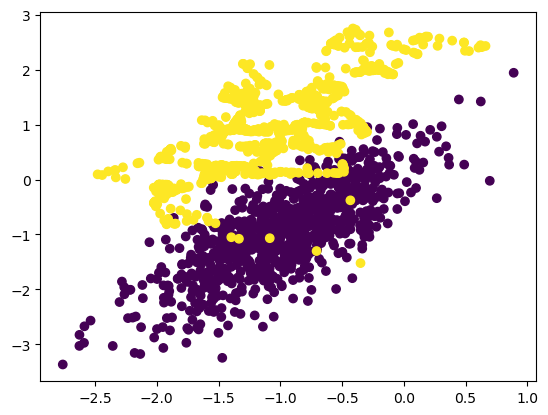

In [31]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])